구글 Colab에서 진행

# 텍스트 마이닝
- 텍스트로부터 정보를 추출해내는 기법

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = "/content/drive/MyDrive/01_Machain Learning/4. 텍스트 마이닝/data/Amazon_Unlocked_Mobile.csv"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(FILE_PATH)
df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    348669 non-null  object 
 2   Price         407907 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413770 non-null  object 
 5   Review Votes  401544 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB


In [ ]:
df.isnull()

# df.isnull()은 판다스(Pandas) 라이브러리에서 제공하는 메서드로, 데이터프레임(df) 내의 각 요소가 결측값(NaN, NA, None 등)인지 여부를 검사합니다.
# 이 메서드는 데이터프레임과 같은 형태의 새로운 데이터프레임을 반환하며, 각 위치의 값이 결측값이라면 True, 아니면 False를 가집니다.

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
413835,False,False,False,False,False,False
413836,False,False,False,False,False,False
413837,False,False,False,False,False,False
413838,False,False,False,False,False,False


# 시각화

In [ ]:
sns.set_theme(style='whitegrid', palette='pastel')

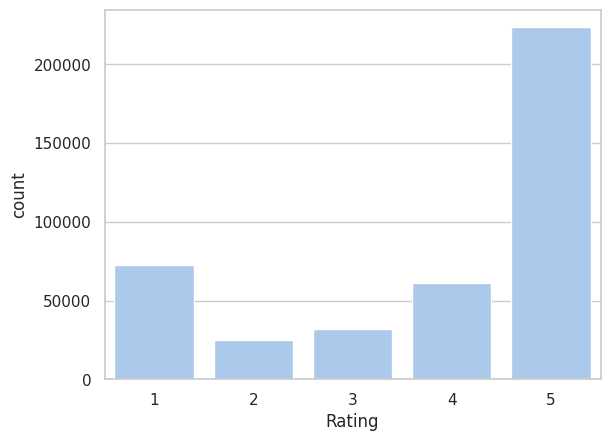

In [ ]:
sns.countplot(x='Rating', data=df)
plt.show()

In [ ]:
# 리뷰의 글자 수 확인
df['Reviews'].dropna().map(len)

# dropna()는 판다스(Pandas) 라이브러리에서 제공하는 메서드로, 데이터프레임에서 결측값이 있는 행이나 열을 삭제할 때 사용됩니다.
# dropna() 메서드는 다양한 인자들을 통해 행(row) 또는 열(column)을 선택적으로 삭제할 수 있습니다.

0         374
1         214
2          12
3          76
4         223
         ... 
413835     30
413836      2
413837     43
413838     92
413839     83
Name: Reviews, Length: 413770, dtype: int64

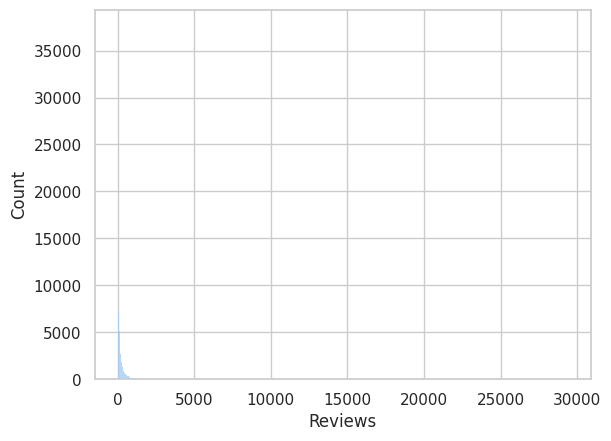

In [ ]:
# 리뷰의 길이 분포 (글자 수)
sns.histplot(df['Reviews'].dropna().map(len))
plt.show()

In [ ]:
# 가장 긴 리뷰의 글자 수
df['Reviews'].dropna().map(len).max()
# -> 일반적이지 않은 상황은 제거해주는 것이 좋을 듯

29419

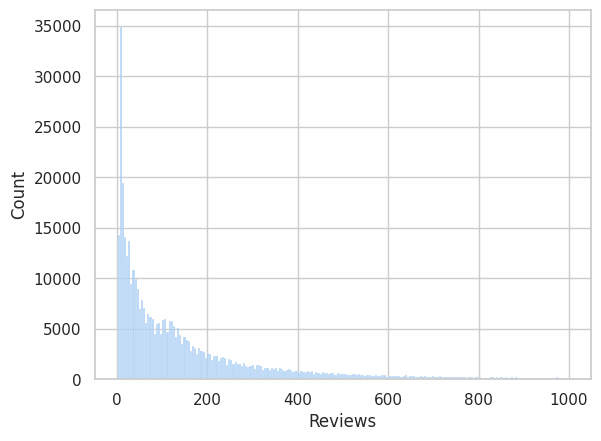

In [ ]:
# 1000글자 미만의 리뷰만 시각화

reviews_chars = df['Reviews'].dropna().map(len)
reviews_chars_under_1000_mask = reviews_chars < 1000

sns.histplot(reviews_chars[reviews_chars_under_1000_mask])
plt.show()

In [ ]:
# 리뷰 단어의 개수
df['Reviews'].dropna().map(lambda x : len(x.split()))

0         72
1         40
2          2
3         17
4         43
          ..
413835     5
413836     1
413837     7
413838    19
413839    13
Name: Reviews, Length: 413770, dtype: int64

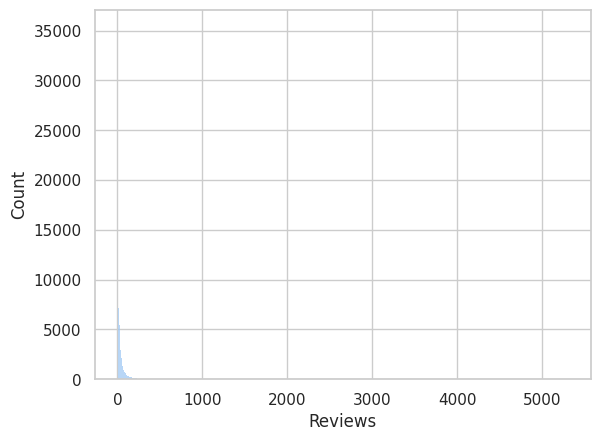

In [ ]:
sns.histplot(df['Reviews'].dropna().map(lambda x : len(x.split())))
plt.show()

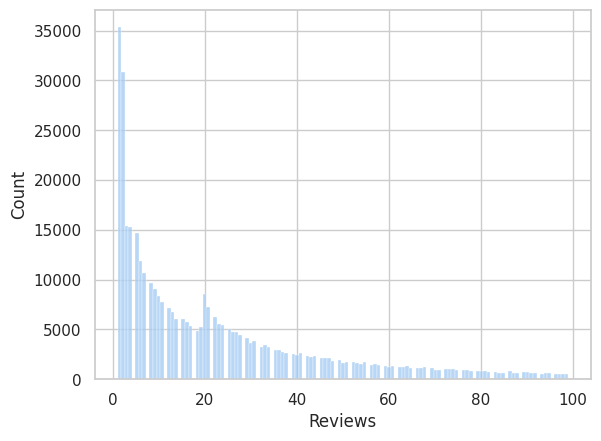

In [ ]:
# 위의 글자수 경우와 동일한 이유로 단어의 개수를 100개 이하인 리뷰만 추출

reviews_words = df['Reviews'].dropna().map(lambda x : len(x.split()))
reviews_words_under_100_mask = reviews_words < 100

sns.histplot(reviews_words[reviews_words_under_100_mask])
plt.show()

In [ ]:
#리뷰의 길이와 투표 수(Review Vote)의 상관 관계

df['Review Words'] = df["Reviews"].dropna().map(lambda x : len(x.split()))

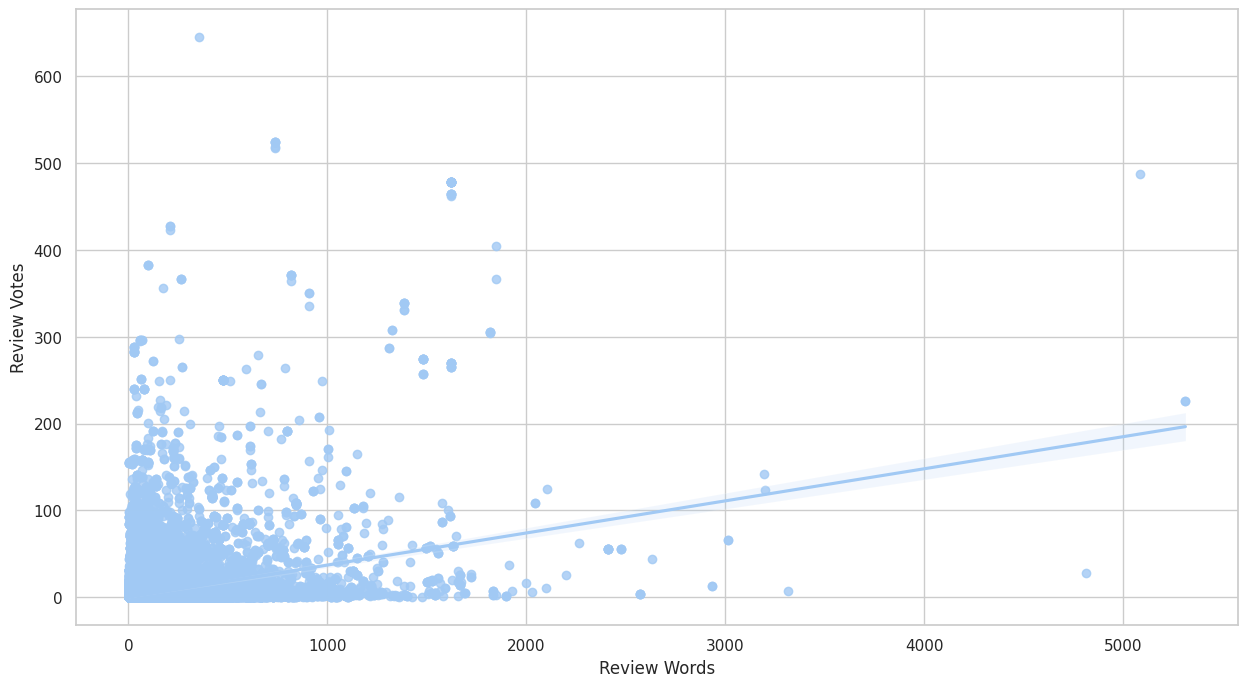

In [ ]:
plt.figure(figsize=(15, 8))

sns.regplot(x='Review Words', y='Review Votes', data=df)
plt.show()

In [ ]:
# 애플과 삼성의 평균 평점
df[df['Brand Name'] == "Samsung"]['Rating'].mean()

3.9623556968378786

In [ ]:
df[df['Brand Name'] == "Apple"]["Rating"].mean()

3.9244148076856975

텍스트 마이닝을 통해 삼성과 애플 핸드폰의 부정/긍정적인 리뷰에 대한 단어(키워드)를 분석

In [ ]:
import nltk
from nltk.corpus import stopwords # stopwords = 불용어


nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 불용어 제거하기

In [ ]:
stopwords.words("english")[:10]

In [ ]:
from nltk import word_tokenize

sample_review = df.loc[0, 'Reviews']
print(sample_review)

In [ ]:
# 영어는 일반적으로 소문자로 만들어 준 다음 전처리를 수행
sample_review_lower = sample_review.lower()
print(word_tokenize(sample_review_lower))

In [ ]:
sample_review_word_tokens = word_tokenize(sample_review_lower)
sample_review_word_without_stopwords = [token for token in sample_review_word_tokens if token not in stopwords.words("english")]

sample_review_word_without_stopwords

['feel',
 'lucky',
 'found',
 'used',
 '(',
 'phone',
 'us',
 '&',
 'used',
 'hard',
 ')',
 ',',
 'phone',
 'line',
 'someone',
 'upgraded',
 'sold',
 'one',
 '.',
 'son',
 'liked',
 'old',
 'one',
 'finally',
 'fell',
 'apart',
 '2.5+',
 'years',
 "n't",
 'want',
 'upgrade',
 '!',
 '!',
 'thank',
 'seller',
 ',',
 'really',
 'appreciate',
 '&',
 'honesty',
 ':',
 'said',
 'used',
 'phone.i',
 'recommend',
 'seller',
 'highly',
 '&',
 'would',
 '!',
 '!']

## 아마존 스마트폰 리뷰 워드 클라우드 그리기

In [ ]:
# 데이터가 너무 많아서 시간이 오래 걸리니까, 데이터를 1%만 랜덤으로 뽑아서 확인
df_sample = df.dropna().sample(frac=0.01)
df_sample.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Review Words
327328,Samsung Galaxy Note 4 N910H Unlocked Cellphone...,Samsung,320.61,5,"i love the screen resolution , it is amazing ,...",0.0,24.0
74949,Apple iPhone SE Unlocked Phone - 64 GB Retail ...,Apple,505.99,5,👍👍👍👍👍👍,0.0,1.0
249629,Motorola KRZR K1 Unlocked Cell Phone with 2 MP...,Motorola,83.99,1,It looked like a great phone for me to use int...,0.0,30.0
65355,Apple iPhone 6s 128 GB US Warranty Unlocked Ce...,"Amazon.com, LLC *** KEEP PORules ACTIVE ***",629.99,5,Perfect,0.0,1.0
211814,LG Electronics G3 D855 32GB Unlocked Internati...,LG Electronics,561.11,5,"I just received my LG G3 3RAM, five days ago. ...",0.0,81.0
...,...,...,...,...,...,...,...
117532,BLU Diva Flex 2.4 - Flip phone - unlocked Dual...,BLU,29.99,2,the cover is so hard to open to insert the sim...,0.0,19.0
315570,Samsung Galaxy J1 J105M Mini LTE 8GB Dual Sim ...,Samsung,81.24,1,"After new SW updated, sim1 is not working.",1.0,8.0
296139,"POSH MOBILE LYNX GSM UNLOCKED DUAL SIM 1.8"" GS...",Posh Mobile,24.00,5,FINE,0.0,1.0
259502,Nokia - 106.3 Negro/black Unlocked Dualband GS...,Nokia,269.10,4,goob,0.0,1.0


In [ ]:
# wordcloud는 문장 내 단어 빈도가 중요하기 때문에 모든 리뷰를 한 줄로 이어도 상관 없다

all_reviews = " ".join(df_sample['Reviews'])
all_reviews

'i love the screen resolution , it is amazing ,, and the camera it is professional camera u cant imagine how accurate it is 👍👍👍👍👍👍 It looked like a great phone for me to use internationaly but unfortunatly the seller does not read your e-mails and does not follow through with the promises they make. Perfect I just received my LG G3 3RAM, five days ago. I`ve watched tons of reviews before buying this amazing phone. And now that I have it is just exactly what I was expecting. If you have. A little more than 400 bucks don\'t waste your time looking for any other cellphone. This is the best you will find for that price. I really love this LG G3. Even the TV commercial is the best xD. I so happy now. Thanks LG! This is a great phone. For how much it\'s selling for right now, if you need a cost effective, functional smartphone that also looks good (great for the price range) this is a good choice. Also, when reading pro reviews, a lot of reviewers complained about the screen quality. For the

In [ ]:
all_reviews_lower = all_reviews.lower()
all_reviews_lower

'i love the screen resolution , it is amazing ,, and the camera it is professional camera u cant imagine how accurate it is 👍👍👍👍👍👍 it looked like a great phone for me to use internationaly but unfortunatly the seller does not read your e-mails and does not follow through with the promises they make. perfect i just received my lg g3 3ram, five days ago. i`ve watched tons of reviews before buying this amazing phone. and now that i have it is just exactly what i was expecting. if you have. a little more than 400 bucks don\'t waste your time looking for any other cellphone. this is the best you will find for that price. i really love this lg g3. even the tv commercial is the best xd. i so happy now. thanks lg! this is a great phone. for how much it\'s selling for right now, if you need a cost effective, functional smartphone that also looks good (great for the price range) this is a good choice. also, when reading pro reviews, a lot of reviewers complained about the screen quality. for the

In [ ]:
# 토큰화

all_reviews_tokens = word_tokenize(all_reviews_lower)
all_reviews_tokens[:10]

['i', 'love', 'the', 'screen', 'resolution', ',', 'it', 'is', 'amazing', ',']

In [ ]:
# 불용어 제거

all_reviews_tokens_clean = [token for token in all_reviews_tokens if token not in stopwords.words("english")]
all_reviews_tokens_clean[:10]


['love',
 'screen',
 'resolution',
 ',',
 'amazing',
 ',',
 ',',
 'camera',
 'professional',
 'camera']

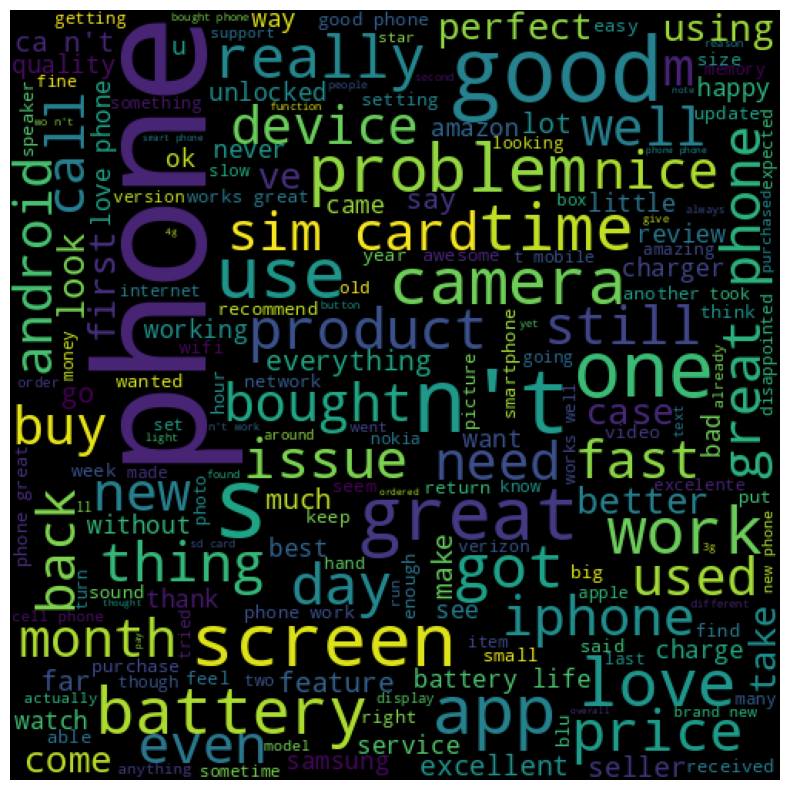

In [ ]:
from wordcloud import WordCloud

# 워드클라우드는 값이 큰 리뷰에 대해 글씨 크기를 크게 설정, 값이 작은 리뷰에 대해서는 작게 표현
# Ex) apple : 100, banana : 30
wc = WordCloud(max_font_size=100, width=500, height=500)

# 문장 기반으로 단어들의 wordcloud 그리기
all_reviews_wc = wc.generate(' '.join(all_reviews_tokens_clean))

plt.figure(figsize=(10, 10))
plt.imshow(all_reviews_wc)
plt.axis('off')

plt.show()

In [ ]:
# 워드 클라우드를 여러번 그리면서 전처리 과정을 간소화 하기 위해 함수로 만들어 놓기
def clean_reviews(df):

  # 데이터 프레임의 리뷰를 하나의 문자열로 이어주기
  reviews = ' '.join(df['Reviews'])

  # 소문자화 수행
  reviews_lower = reviews.lower()

  # 토큰화
  reviews_tokens = word_tokenize(reviews_lower)

  # 불용어 제거
  reviews_tokens_clean = [ token for token in reviews_tokens if token not in stopwords.words("english") ]

  return reviews_tokens_clean

def draw_wordcloud(df):
  global wc

  # 전처리가 완료된 토큰 얻어내기
  reviews_tokens_clean = clean_reviews(df)

  # 워드클라우드 그리기(이미지 받기)
  reviews_wc = wc.generate(' '.join(reviews_tokens_clean))

  return reviews_wc

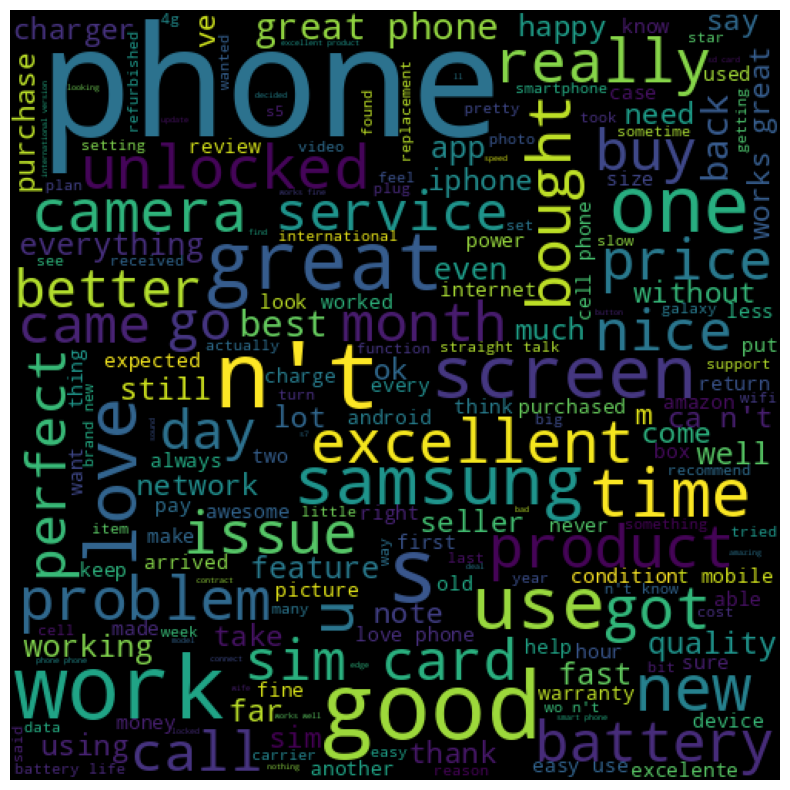

In [ ]:
# 삼성 폰에 대해서만 워드 클라우드 그리기

df_samsung = df_sample[df_sample['Brand Name'] == "Samsung"]

samsung_review_wc = draw_wordcloud(df_samsung)

plt.figure(figsize=(10, 10))
plt.imshow(samsung_review_wc)
plt.axis('off')

plt.show()

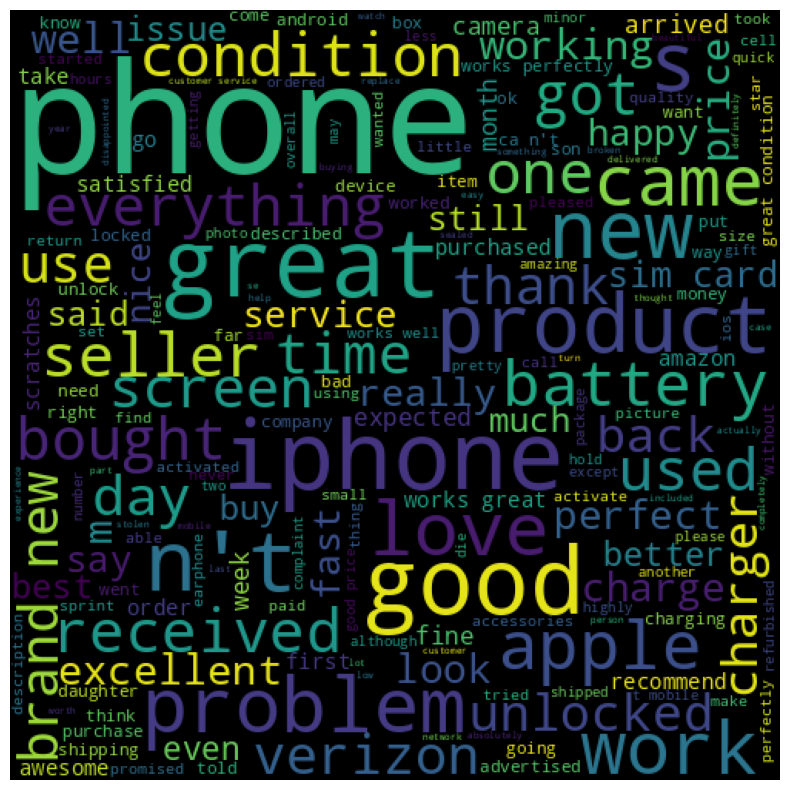

In [ ]:
# 애플 폰에 대해서만 워드 클라우드 그리기

df_apple = df_sample[df_sample['Brand Name'] == "Apple"]

apple_review_wc = draw_wordcloud(df_apple)

plt.figure(figsize=(10, 10))
plt.imshow(apple_review_wc)
plt.axis('off')

plt.show()

# Spacy 사용하기

In [ ]:
import spacy

# 단어 사전 다운로드
nlp = spacy.load("en_core_web_sm")

In [ ]:
test_sentence = """I'm at a payphone, trying to call home. All of my change I spent on you. Where have the times gone.. Baby, it's all wrong. Where are the plans we made for two."""

In [ ]:
doc = nlp(test_sentence)
doc.text

"I'm at a payphone, trying to call home. All of my change I spent on you. Where have the times gone.. Baby, it's all wrong. Where are the plans we made for two."

In [ ]:
# spacy에 통과시킨 doc로 부터 각 단어의 정보를 확인할 수 있다.
for word_token in doc:
  print("word : {}\t\tPOS : {}\t\tLemma : {}".format(word_token.text, word_token.pos_, word_token.lemma_))

#Lemma = 원형

word : I		POS : PRON		Lemma : I
word : 'm		POS : AUX		Lemma : be
word : at		POS : ADP		Lemma : at
word : a		POS : DET		Lemma : a
word : payphone		POS : NOUN		Lemma : payphone
word : ,		POS : PUNCT		Lemma : ,
word : trying		POS : VERB		Lemma : try
word : to		POS : PART		Lemma : to
word : call		POS : VERB		Lemma : call
word : home		POS : NOUN		Lemma : home
word : .		POS : PUNCT		Lemma : .
word : All		POS : PRON		Lemma : all
word : of		POS : ADP		Lemma : of
word : my		POS : PRON		Lemma : my
word : change		POS : NOUN		Lemma : change
word : I		POS : PRON		Lemma : I
word : spent		POS : VERB		Lemma : spend
word : on		POS : ADP		Lemma : on
word : you		POS : PRON		Lemma : you
word : .		POS : PUNCT		Lemma : .
word : Where		POS : SCONJ		Lemma : where
word : have		POS : AUX		Lemma : have
word : the		POS : DET		Lemma : the
word : times		POS : NOUN		Lemma : time
word : gone		POS : VERB		Lemma : go
word : ..		POS : PUNCT		Lemma : ..
word : Baby		POS : PROPN		Lemma : Baby
word : ,		POS : PUNCT		Lemma 

In [ ]:
# 반복문에서 현재 진행 상황이 얼마나 되는지를 표시
from tqdm import tqdm

under_100_words_mask = df_sample.dropna()['Review Words'] < 100

df_sample_under_100 = df_sample[under_100_words_mask]

df_sample_under_100

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Review Words
327328,Samsung Galaxy Note 4 N910H Unlocked Cellphone...,Samsung,320.61,5,"i love the screen resolution , it is amazing ,...",0.0,24.0
74949,Apple iPhone SE Unlocked Phone - 64 GB Retail ...,Apple,505.99,5,👍👍👍👍👍👍,0.0,1.0
249629,Motorola KRZR K1 Unlocked Cell Phone with 2 MP...,Motorola,83.99,1,It looked like a great phone for me to use int...,0.0,30.0
65355,Apple iPhone 6s 128 GB US Warranty Unlocked Ce...,"Amazon.com, LLC *** KEEP PORules ACTIVE ***",629.99,5,Perfect,0.0,1.0
211814,LG Electronics G3 D855 32GB Unlocked Internati...,LG Electronics,561.11,5,"I just received my LG G3 3RAM, five days ago. ...",0.0,81.0
...,...,...,...,...,...,...,...
117532,BLU Diva Flex 2.4 - Flip phone - unlocked Dual...,BLU,29.99,2,the cover is so hard to open to insert the sim...,0.0,19.0
315570,Samsung Galaxy J1 J105M Mini LTE 8GB Dual Sim ...,Samsung,81.24,1,"After new SW updated, sim1 is not working.",1.0,8.0
296139,"POSH MOBILE LYNX GSM UNLOCKED DUAL SIM 1.8"" GS...",Posh Mobile,24.00,5,FINE,0.0,1.0
259502,Nokia - 106.3 Negro/black Unlocked Dualband GS...,Nokia,269.10,4,goob,0.0,1.0


In [ ]:
# 모든 리뷰를 소문자로 변경

df_sample_under_100['Reviews lower'] = df_sample["Reviews"].apply(lambda x : x.lower())
df_sample_under_100.head()

<ipython-input-85-7629d8c37676>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample_under_100['Reviews lower'] = df_sample["Reviews"].apply(lambda x : x.lower())


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Review Words,Reviews lower
327328,Samsung Galaxy Note 4 N910H Unlocked Cellphone...,Samsung,320.61,5,"i love the screen resolution , it is amazing ,...",0.0,24.0,"i love the screen resolution , it is amazing ,..."
74949,Apple iPhone SE Unlocked Phone - 64 GB Retail ...,Apple,505.99,5,👍👍👍👍👍👍,0.0,1.0,👍👍👍👍👍👍
249629,Motorola KRZR K1 Unlocked Cell Phone with 2 MP...,Motorola,83.99,1,It looked like a great phone for me to use int...,0.0,30.0,it looked like a great phone for me to use int...
65355,Apple iPhone 6s 128 GB US Warranty Unlocked Ce...,"Amazon.com, LLC *** KEEP PORules ACTIVE ***",629.99,5,Perfect,0.0,1.0,perfect
211814,LG Electronics G3 D855 32GB Unlocked Internati...,LG Electronics,561.11,5,"I just received my LG G3 3RAM, five days ago. ...",0.0,81.0,"i just received my lg g3 3ram, five days ago. ..."


In [ ]:
%%time
# %%time 매직 명령어는 Jupyter 노트북에서 사용되는 IPython 매직 명령어 중 하나로, 셀의 실행 시간을 측정하는 데 사용

tokens_preprocessed = []

for doc in tqdm(nlp.pipe(df_sample_under_100["Reviews lower"])):
  # 각 단어의 어간(lemma)를 구한 토큰
  lemmatized_tokens = [ token.lemma_ for token in doc if not token.is_punct and not token.is_space and not token.is_stop ]
  tokens_preprocessed.append(lemmatized_tokens)

tokens_preprocessed[:3]

3043it [00:10, 277.86it/s]

CPU times: user 10.8 s, sys: 24.9 ms, total: 10.8 s
Wall time: 11 s


[['love',
  'screen',
  'resolution',
  'amazing',
  'camera',
  'professional',
  'camera',
  'u',
  'not',
  'imagine',
  'accurate'],
 ['👍', '👍', '👍', '👍', '👍', '👍'],
 ['look',
  'like',
  'great',
  'phone',
  'use',
  'internationaly',
  'unfortunatly',
  'seller',
  'read',
  'e',
  'mail',
  'follow',
  'promise']]

### Bigram & Trigram

- 바이그램(Bigram)
바이그램은 연속된 두 개의 단어로 이루어진 묶음입니다. 텍스트에서 단어 쌍을 생성하여 각각의 빈도를 계산할 수 있습니다. 빅람은 문맥을 이해하는 데 도움을 주며, 다음 단어를 예측하는 작업에 유용합니다.

예시
문장: "I love natural language processing"

Bigrams: [(I, love), (love, natural), (natural, language), (language, processing)]

- 트라이그램(Trigram)
트라이그램은 연속된 세 개의 단어로 이루어진 묶음입니다. 빅람보다 더 많은 문맥 정보를 제공합니다. 트라이그램은 텍스트의 구조를 더 잘 이해하고 더 정교한 모델을 만드는 데 유용합니다.

예시
문장: "I love natural language processing"

Trigrams: [(I, love, natural), (love, natural, language), (natural, language, processing)]

In [ ]:
# gensim 패키지 활용. gengim 패키지는 자연어 처리 관련 여러 라이브리러를 포함
from gensim.models.phrases import Phrases, Phraser

sentences = [
    '피카츄 라이츄 파이리 꼬부기',
    '피카츄 라이츄 의 진화 전 포켓몬 입니다',
    '피카츄 라이츄 파이리 꼬부기',
    '피카츄 라이츄 파이리 는 친구 입니다'
]

word_lsts = [ s.split() for s in sentences ]
word_lsts

[['피카츄', '라이츄', '파이리', '꼬부기'],
 ['피카츄', '라이츄', '의', '진화', '전', '포켓몬', '입니다'],
 ['피카츄', '라이츄', '파이리', '꼬부기'],
 ['피카츄', '라이츄', '파이리', '는', '친구', '입니다']]

In [ ]:
# min_count : 바이그램의 최소 등장 횟수
# threshold : 값이 작아지면 작아질 수록 두 토큰을 잘 붙여준다.
#             기본 값은 무조건 10.0이고, 양수. 0.01같이 작은 값으로 설정하면
#             웬만하면 합성어가 된다.
bigram = Phrases(word_lsts, min_count=1, threshold=1, delimiter="_")
bigram_phraser = Phraser(bigram)

for word_list in word_lsts:
  bigram_s = bigram_phraser[word_list]

  print("유니그램 : {}".format(word_list))
  print("바이그램 : {}".format(bigram_s))
  print("-"*40)

유니그램 : ['피카츄', '라이츄', '파이리', '꼬부기']
바이그램 : ['피카츄_라이츄', '파이리_꼬부기']
----------------------------------------
유니그램 : ['피카츄', '라이츄', '의', '진화', '전', '포켓몬', '입니다']
바이그램 : ['피카츄_라이츄', '의', '진화', '전', '포켓몬', '입니다']
----------------------------------------
유니그램 : ['피카츄', '라이츄', '파이리', '꼬부기']
바이그램 : ['피카츄_라이츄', '파이리_꼬부기']
----------------------------------------
유니그램 : ['피카츄', '라이츄', '파이리', '는', '친구', '입니다']
바이그램 : ['피카츄_라이츄', '파이리', '는', '친구', '입니다']
----------------------------------------


In [ ]:
# trigram : 바이그램을 다시한번 묶어주면 된다.
#  bigram_phraser[word_lsts] : 모든 문장에 대한 바이그램
trigram = Phrases(bigram_phraser[word_lsts], min_count=1, threshold=1.0, delimiter="_")
trigram_phraser = Phraser(trigram)

bigram_vocab_set = set(bigram.vocab.keys())
trigram_vocab_set = set(trigram.vocab.keys())

print("== Bigram Model vocab")
print({vocab for vocab in bigram_vocab_set})
print("--"*20)
print("== Trigram Model vocab")
print({vocab for vocab in trigram_vocab_set})
print("--"*20)

== Bigram Model vocab
{'포켓몬', '파이리_는', '꼬부기', '전_포켓몬', '는', '피카츄_라이츄', '포켓몬_입니다', '파이리', '진화', '라이츄_의', '라이츄', '전', '진화_전', '파이리_꼬부기', '피카츄', '입니다', '는_친구', '의_진화', '친구', '의', '친구_입니다', '라이츄_파이리'}
----------------------------------------
== Trigram Model vocab
{'포켓몬', '파이리_는', '전_포켓몬', '는', '피카츄_라이츄', '포켓몬_입니다', '파이리', '진화', '전', '진화_전', '파이리_꼬부기', '입니다', '는_친구', '의_진화', '친구', '의', '피카츄_라이츄_의', '친구_입니다', '피카츄_라이츄_파이리_꼬부기', '피카츄_라이츄_파이리'}
----------------------------------------


## 리뷰 데이터 trigram 만들기

In [ ]:
%%time
bigram_model = Phrases(tokens_preprocessed)
bigram_phraser = Phraser(bigram_model)

CPU times: user 150 ms, sys: 2.25 ms, total: 152 ms
Wall time: 320 ms


In [102]:
# 바이그램 토큰 생성
tokens_bigram = [ bigram_phraser[token] for token in tokens_preprocessed ]
tokens_bigram[:3]

[['love',
  'screen',
  'resolution',
  'amazing',
  'camera',
  'professional',
  'camera',
  'u',
  'not',
  'imagine',
  'accurate'],
 ['👍_👍', '👍_👍', '👍_👍'],
 ['look',
  'like',
  'great',
  'phone',
  'use',
  'internationaly',
  'unfortunatly',
  'seller',
  'read',
  'e',
  'mail',
  'follow',
  'promise']]

In [101]:
# 트라이그램 토큰 생성
trigram_model = Phrases(tokens_bigram) # 바이그램 토큰으로 트라이그램 토큰 생성
trigram_phraser = Phraser(trigram_model)

In [103]:
tokens_trigram = [ trigram_phraser[token] for token in tokens_bigram ]
tokens_trigram[:3]

[['love',
  'screen',
  'resolution',
  'amazing',
  'camera',
  'professional',
  'camera',
  'u',
  'not',
  'imagine',
  'accurate'],
 ['👍_👍', '👍_👍', '👍_👍'],
 ['look',
  'like',
  'great',
  'phone',
  'use',
  'internationaly',
  'unfortunatly',
  'seller',
  'read',
  'e',
  'mail',
  'follow',
  'promise']]

In [105]:
# 트라이그램 토큰을 각각 문장으로 만들어서 집어 넣기
df_sample_under_100['Review Preprocessed'] = [' '.join(tokens) for tokens in tokens_trigram ]
df_sample_under_100

<ipython-input-105-d78428849b5c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample_under_100['Review Preprocessed'] = [' '.join(tokens) for tokens in tokens_trigram ]


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Review Words,Reviews lower,Review Preprocessed
327328,Samsung Galaxy Note 4 N910H Unlocked Cellphone...,Samsung,320.61,5,"i love the screen resolution , it is amazing ,...",0.0,24.0,"i love the screen resolution , it is amazing ,...",love screen resolution amazing camera professi...
74949,Apple iPhone SE Unlocked Phone - 64 GB Retail ...,Apple,505.99,5,👍👍👍👍👍👍,0.0,1.0,👍👍👍👍👍👍,👍_👍 👍_👍 👍_👍
249629,Motorola KRZR K1 Unlocked Cell Phone with 2 MP...,Motorola,83.99,1,It looked like a great phone for me to use int...,0.0,30.0,it looked like a great phone for me to use int...,look like great phone use internationaly unfor...
65355,Apple iPhone 6s 128 GB US Warranty Unlocked Ce...,"Amazon.com, LLC *** KEEP PORules ACTIVE ***",629.99,5,Perfect,0.0,1.0,perfect,perfect
211814,LG Electronics G3 D855 32GB Unlocked Internati...,LG Electronics,561.11,5,"I just received my LG G3 3RAM, five days ago. ...",0.0,81.0,"i just received my lg g3 3ram, five days ago. ...",receive lg g3 3ram day ago i`ve watch ton revi...
...,...,...,...,...,...,...,...,...,...
117532,BLU Diva Flex 2.4 - Flip phone - unlocked Dual...,BLU,29.99,2,the cover is so hard to open to insert the sim...,0.0,19.0,the cover is so hard to open to insert the sim...,cover hard open insert sim_card battery font s...
315570,Samsung Galaxy J1 J105M Mini LTE 8GB Dual Sim ...,Samsung,81.24,1,"After new SW updated, sim1 is not working.",1.0,8.0,"after new sw updated, sim1 is not working.",new sw update sim1 work
296139,"POSH MOBILE LYNX GSM UNLOCKED DUAL SIM 1.8"" GS...",Posh Mobile,24.00,5,FINE,0.0,1.0,fine,fine
259502,Nokia - 106.3 Negro/black Unlocked Dualband GS...,Nokia,269.10,4,goob,0.0,1.0,goob,goob


## TfidfVectorizer 사용
- 각 단어의 문장 내 중요도를 보고 중요한 단어들을 더 크게 워드클라우드로 그리겠다.

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

review_tfidf_vectorizer = TfidfVectorizer().fit(df_sample_under_100['Review Preprocessed'])

In [107]:
# documents : 사용자가 입력한 리뷰
  # ex) 삼성 갤럭시 리뷰 중 좋은 평가를 받은 리뷰
def average_tfidf_score(documents):

  # 입력된 리뷰에 대한 tfidf 구해내기
  tfidf_scores = review_tfidf_vectorizer.transform(documents)

  # 단어와, 그 단어에 대한 tfidf 점수의 합을 저장할 딕셔너리
  scores = {}

  # 단어 별 점수 구하기
  for document, tfidf_score in zip(documents, tfidf_scores):
    # spacy를 통한 전처리 작업을 그대로 수행
    doc = nlp(document)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and not token.is_stop ]

    # 각 문서 별 단어를 꺼내서
    for term in lemmatized_tokens:
      # tfidf 의 단어 집합에 존재한다면
      if term in review_tfidf_vectorizer.vocabulary_.keys():

        # 점수를 구해서 합해주기
        # tfidf_score[0, ...] : tfidf_score는 2차원 배열인데, 하나씩 들어오기 때문에 tfidf_score의 shape은 (1, vocab_size)
        scores[term] = tfidf_score[0, review_tfidf_vectorizer.vocabulary_[str(term).strip()]] + scores.get(term, 0)

  return scores

In [108]:
# 애플의 좋은 리뷰에 대한 단어를 워드 클라우드로 분석
df_apple = df_sample_under_100[df_sample_under_100['Brand Name'] == "Apple"]
df_apple_rating_over_3 = df_apple[df_apple["Rating"] > 3]
df_apple_rating_over_3

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Review Words,Reviews lower,Review Preprocessed
74949,Apple iPhone SE Unlocked Phone - 64 GB Retail ...,Apple,505.99,5,👍👍👍👍👍👍,0.0,1.0,👍👍👍👍👍👍,👍_👍 👍_👍 👍_👍
34508,Apple iPhone 5c 8GB (Yellow) - Verizon Wireless,Apple,179.99,5,The product looks new! The only thing I was a ...,0.0,20.0,the product looks new! the only thing i was a ...,product look new thing little_bit happy come h...
32559,Apple iPhone 5c 32GB (White) - AT&T,Apple,279.95,4,Phone is in awesome condition except didn't co...,0.0,23.0,phone is in awesome condition except didn't co...,phone awesome condition come accsesorie charge...
12097,Apple iPhone 4S 16GB (Black) - Verizon,Apple,224.77,5,"I got the 16g black iPhone 4S, and it is amazi...",0.0,45.0,"i got the 16g black iphone 4s, and it is amazi...",get 16 g black iphone 4s amazing arrive super_...
37724,"Apple iPhone 5c A1532, 8 GB, Factory Unlocked ...",Apple,159.99,5,Purchased this for my mom. She loves it.. came...,15.0,36.0,purchased this for my mom. she loves it.. came...,purchase mom love come promise arrive immacula...
...,...,...,...,...,...,...,...,...,...
25194,Apple iPhone 5c 16GB (Pink) - AT&T,Apple,519.00,5,"This is a awesome Case , Got this for my Siste...",0.0,27.0,"this is a awesome case , got this for my siste...",awesome case get sister -n law christmas look ...
76325,Apple iPhone SE Unlocked Phone -16 GB Retail P...,Apple,448.98,5,I am writing through my new iphone SE. No prob...,0.0,21.0,i am writing through my new iphone se. no prob...,write new iphone se problem unblocked package ...
40523,Apple iPhone 5s 16GB (Silver) - Verizon Wireless,Apple,149.99,5,Purchased this phone brand new and it's amazin...,0.0,44.0,purchased this phone brand new and it's amazin...,purchase phone brand_new amazing well expect c...
27343,Apple iPhone 5c 32GB - Unlocked - (Blue),Apple,224.77,5,it was a gift for my Mum in Mexico and it work...,0.0,17.0,it was a gift for my mum in mexico and it work...,gift mum mexico work_perfectly mex company


In [109]:
# 애플 스마트폰에 대한 긍정적인 평가의 각 단어 별 tfidf 점수합 확인
apple_positive_review_tfidf_scores = average_tfidf_score(df_apple_rating_over_3['Review Preprocessed'])
apple_positive_review_tfidf_scores

{'product': 17.004556713417646,
 'look': 6.78623356363598,
 'new': 11.46284621446331,
 'thing': 1.8594756943469355,
 'little_bit': 0.8364882417776451,
 'happy': 6.275668768773541,
 'come': 9.11660006937882,
 'headphone': 0.44850576848262674,
 'phone': 32.6676632113619,
 'awesome': 7.2168873579794575,
 'condition': 16.358943927907966,
 'accsesorie': 1.1277531004849604,
 'charger': 3.0216272028073554,
 'star': 0.6200429720415231,
 '16': 0.32657111263664906,
 'black': 0.25565474581942876,
 'iphone': 14.62160631997967,
 '4s': 1.3812534525904767,
 'amazing': 2.0398844021970186,
 'arrive': 3.9309740388387566,
 'super_fast': 1.1943801413875725,
 'brand_new': 6.569886020660796,
 'able': 0.9420437607051146,
 'verizon': 2.227865275936403,
 'activate': 1.9484063968153738,
 'problem': 8.289075797523898,
 'fantastic': 0.8795599368096849,
 'job': 0.2781631613567741,
 'recommend': 2.240106960803908,
 'purchase': 2.726656863743912,
 'mom': 0.64353328243299,
 'love': 19.4002058577629,
 'promise': 3.335

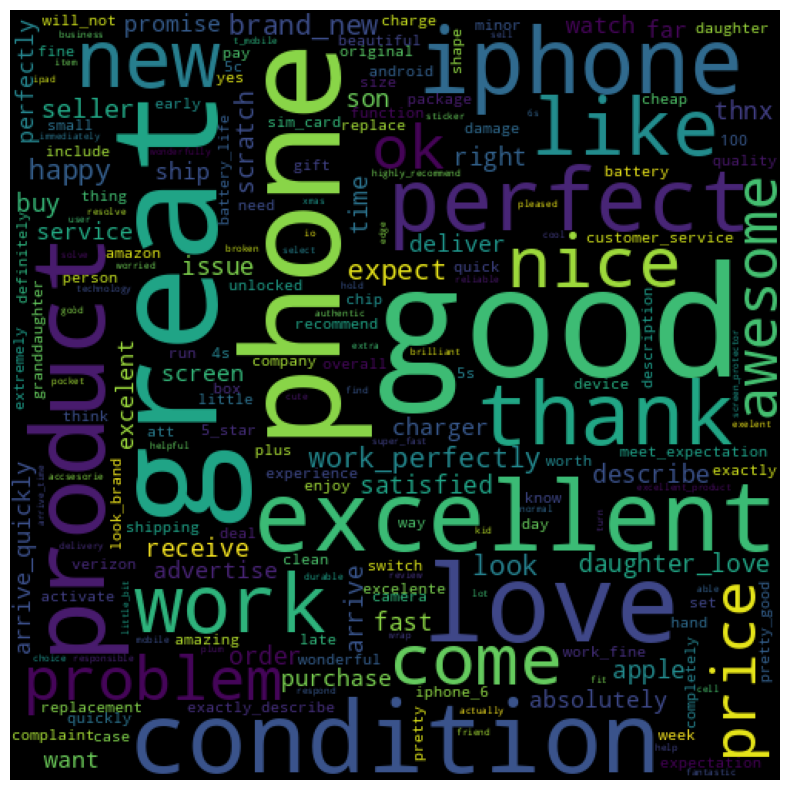

In [110]:
apple_positive_tfidf_wc = wc.generate_from_frequencies(apple_positive_review_tfidf_scores)

plt.figure(figsize=(10, 10))
plt.axis('off')
plt.imshow(apple_positive_tfidf_wc)
plt.show()